In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print(tf.__version__)

2.10.0


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Scale pixel values to [0, 1]
    rotation_range=20,  # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,  # Randomly shift the width of the image
    height_shift_range=0.2,  # Randomly shift the height of the image
    horizontal_flip=True,  # Randomly flip images horizontally
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Randomly zoom into images
    fill_mode="nearest"  # Fill in missing pixels using the nearest neighbor
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

: 

: 

In [ ]:
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(224, 224),  # Resize images to a specific size
    batch_size=8,  # Set the batch size based on your hardware capabilities
    class_mode='categorical',  # Specify the type of classification task
    shuffle=True  # Shuffle the data for better training
)

test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False  # Don't shuffle the test data
)

Found 330 images belonging to 3 classes.
Found 85 images belonging to 3 classes.


: 

: 

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets (80% train, 20% validation)
train_data, val_data = train_test_split(train_generator, test_size=0.2, random_state=13)

: 

: 

In [ ]:
model = tf.keras.Sequential([
    # Add your convolutional and pooling layers here
    # For example:
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # ...
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes (healthy, caterpillar, leafspot)
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model using the train_generator
model.fit(train_generator, epochs=10, validation_data=val_data)

Epoch 1/10
42/42 [==============================] - 71s 2s/step - loss: 4.0358 - accuracy: 0.4758 - val_loss: 1.0103 - val_accuracy: 0.6353
Epoch 2/10
42/42 [==============================] - 71s 2s/step - loss: 0.8449 - accuracy: 0.6303 - val_loss: 0.8612 - val_accuracy: 0.6941
Epoch 3/10
42/42 [==============================] - 73s 2s/step - loss: 0.7828 - accuracy: 0.6788 - val_loss: 0.6564 - val_accuracy: 0.7647
Epoch 4/10
42/42 [==============================] - 69s 2s/step - loss: 0.7580 - accuracy: 0.6970 - val_loss: 0.7401 - val_accuracy: 0.7529
Epoch 5/10
42/42 [==============================] - 68s 2s/step - loss: 0.5871 - accuracy: 0.7788 - val_loss: 0.9179 - val_accuracy: 0.7059
Epoch 6/10
42/42 [==============================] - 69s 2s/step - loss: 0.6784 - accuracy: 0.7424 - val_loss: 0.6068 - val_accuracy: 0.7176
Epoch 7/10
42/42 [==============================] - 64s 2s/step - loss: 0.6040 - accuracy: 0.7697 - val_loss: 1.3638 - val_accuracy: 0.6353
Epoch 8/10
42/42 [==

: 

: 

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 394272)            0         
                                                                 
 dense (Dense)               (None, 3)                 1182819   
                                                                 
Total params: 1,183,715
Trainable params: 1,183,715
Non-trainable params: 0
_________________________________________________________________


: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluate the model on the test data
test_results = model.evaluate(test_generator)

# Make predictions on the test data
y_pred = model.predict(test_generator)
# Convert one-hot encoded labels back to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the actual class labels from the test generator
y_true = test_generator.classes

# Generate the classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices)

print("Classification Report:")
print(class_report)

# Generate the confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


: 

11/11 [==============================] - 13s 1s/step
Classification Report:
              precision    recall  f1-score   support

 caterpiller       0.83      0.76      0.79        33
     healthy       0.49      0.82      0.61        28
    leafspot       1.00      0.33      0.50        24

    accuracy                           0.66        85
   macro avg       0.77      0.64      0.64        85
weighted avg       0.77      0.66      0.65        85



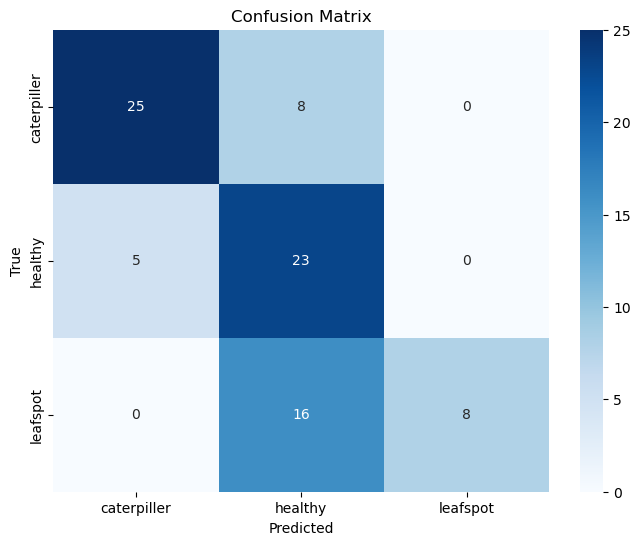

: 

In [ ]:
## validation using test data